Loading Inputs for Autoencoder-Based Anomaly Detection

The autoencoder analysis begins by loading the preprocessed inputs required for consistent and reproducible modeling. The scaled numerical feature matrix (X_scaled.npy) is loaded as the primary model input, ensuring that the autoencoder operates on the same standardized representation previously used for Isolation Forest. This consistency enables direct comparison and integration of results across anomaly detection methods.

The corresponding list of numerical feature names is loaded from a persistent text file to preserve feature alignment and support interpretability in subsequent analysis and visualization. In parallel, the cleaned transaction dataset is loaded to provide transaction-level identifiers, timestamps, and address information required for contextual interpretation and reporting.

Additionally, the previously saved Isolation Forest results are loaded to enable coordination between the two anomaly detection approaches. Shape consistency checks are applied to verify alignment between the scaled feature matrix, feature names, and transaction records, preventing silent mismatches between model inputs and associated metadata. These steps establish a reliable and coherent data foundation for autoencoder training and evaluation.

In [42]:
import numpy as np
import pandas as pd

# Load scaled feature matrix (used by Isolation Forest)
X_scaled = np.load("../data/processed/X_scaled.npy")

# Load feature names (for reference / plotting)
with open("../data/processed/feature_names.txt") as f:
    numeric_features = [line.strip() for line in f]

# Load cleaned data (for IDs, timestamps, addresses, reporting)
df = pd.read_csv("../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv")

# Load Isolation Forest results
if_results = pd.read_csv("../results/isolation_forest_results.csv")



# Sanity check
assert X_scaled.shape[0] == len(if_results)
assert X_scaled.shape[1] == len(numeric_features)

print("X_scaled shape:", X_scaled.shape)
print("Features:", numeric_features)


X_scaled shape: (1000, 7)
Features: ['amount0', 'amount1', 'sqrtPriceX96', 'liquidity', 'tick', 'gasPrice', 'gasUsed']


Selection of Training and Evaluation Data for the Autoencoder

For the autoencoder-based anomaly detection stage, the scaled feature matrix is partitioned into distinct subsets for model training and evaluation. Training data is restricted to transactions previously classified as normal by the Isolation Forest model. A boolean mask derived from the Isolation Forest anomaly labels is applied to select only those transactions labeled as normal, under the assumption that they represent typical transaction behavior.

This design choice reflects a core principle of reconstruction-based anomaly detection: the autoencoder is trained exclusively on normal data so that it learns a compact representation of regular transaction patterns. As a result, transactions that deviate from these learned patterns are expected to exhibit higher reconstruction errors during evaluation.

In parallel, the complete scaled feature matrix is retained for evaluation and scoring. This allows reconstruction errors to be computed for all transactions, including those identified as anomalous by Isolation Forest. Separating training and evaluation in this manner ensures that the autoencoder’s anomaly scores reflect deviations from learned normal behavior rather than artifacts introduced during training.

In [43]:
#1 AE
# NORMAL data only (training)
normal_mask = if_results["isolation_forest_anomaly"] == 1
X_ae_train = X_scaled[normal_mask.values]

print("AE training shape:", X_ae_train.shape)

# ALL data (scoring / reconstruction error)
X_ae_all = X_scaled

print("AE evaluation shape:", X_ae_all.shape)




AE training shape: (950, 7)
AE evaluation shape: (1000, 7)


Training–Validation Split for Autoencoder Learning

The Isolation Forest–filtered normal transaction data is further divided into training and validation subsets to support reliable autoencoder learning and performance monitoring. A random split is applied to allocate a fixed proportion of the normal data to validation, while the remaining majority is retained for model training.

This separation enables the autoencoder to be trained on one subset of normal transactions while its reconstruction performance is evaluated on unseen normal data during training. Monitoring validation behavior is essential for detecting overfitting and ensuring that the model learns generalizable representations of typical transaction patterns rather than memorizing the training data.

A fixed random seed is specified to guarantee reproducibility of the split. The resulting training and validation sets form the basis for subsequent autoencoder training and optimization.

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

# Split Isolation Forest normal data into train / validation
X_train, X_val = train_test_split(
    X_ae_train,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)


Train shape: (855, 7)
Validation shape: (95, 7)


Autoencoder Architecture Definition and Configuration

An autoencoder neural network is defined to learn a compact representation of normal transaction behavior in the scaled feature space. The model architecture follows a symmetric, fully connected design, consisting of an encoder that progressively reduces dimensionality and a decoder that reconstructs the original input.

The network input dimension is set to match the number of scaled numerical features, ensuring direct correspondence between input and reconstructed output. The encoder compresses the input through successive dense layers, culminating in a low-dimensional bottleneck layer that captures the most salient patterns of normal transaction behavior. The decoder mirrors this structure, expanding the compressed representation back to the original feature dimension.

ReLU activation functions are used in the hidden layers to introduce nonlinearity and enable the model to learn complex feature interactions, while a linear activation is applied to the output layer to support accurate reconstruction of scaled numerical values. The model is optimized using the Adam optimizer and trained to minimize mean squared reconstruction error, which directly measures the discrepancy between original and reconstructed feature vectors.

A model summary is generated to document the architecture and parameterization, supporting transparency and reproducibility of the autoencoder design.

In [45]:
input_dim = X_train.shape[1]

autoencoder = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),        # bottleneck
    Dense(16, activation="relu"),
    Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527 (2.06 KB)

 Trainable params: 527 (2.06 KB)

 Non-trainable params: 0 (0.00 B)

Autoencoder Training Procedure

The autoencoder model is trained using the normal transaction training subset, with the objective of reconstructing its input feature vectors. During training, the same data is provided as both input and target, reflecting the reconstruction-based learning paradigm inherent to autoencoders.

A validation subset of normal transactions is supplied to monitor reconstruction performance on unseen data throughout training. This validation process supports detection of overfitting and ensures that the learned representation generalizes beyond the training samples. Training is performed over a fixed number of epochs with mini-batch optimization, enabling efficient and stable convergence of the model parameters. Shuffling of training samples is applied to prevent ordering effects and to improve learning robustness.

The training process outputs a history of loss values for both training and validation sets, which can be used to assess convergence behavior and reconstruction stability prior to computing anomaly scores.

In [46]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=1
)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7909.6948 - val_loss: 65.1551
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6990.5732 - val_loss: 60.9696
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6102.6616 - val_loss: 57.5493
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5474.1484 - val_loss: 54.1258
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5010.7285 - val_loss: 50.3938
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4664.4722 - val_loss: 47.6742
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3978.1787 - val_loss: 45.3154
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3342.5205 - val_loss: 42.7552
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2621.0198 - val_loss: 39.7716
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1850.8339 - val_loss: 36.4394
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1057.1727 - val_loss: 33.8593
Epoch 12/50
27/27 ━━━━━━━━━━━━

Computation of Reconstruction Errors for Anomaly Scoring

After training, the autoencoder is applied to reconstruct the scaled feature vectors of all transactions in the dataset, including both normal and potentially anomalous observations. For each transaction, the reconstructed output is compared to the original scaled input to evaluate reconstruction quality.

A reconstruction error is computed for each transaction as the mean squared error across all feature dimensions. This reconstruction error serves as a continuous anomaly score, reflecting the degree to which a transaction deviates from the patterns learned during training on normal data. Transactions that conform to typical behavior are reconstructed with low error, whereas transactions exhibiting atypical patterns result in higher reconstruction errors.

The reconstruction error values are stored alongside the corresponding transaction metadata to enable ranking, statistical analysis, and subsequent threshold-based anomaly classification. A descriptive summary of the reconstruction error distribution is generated to characterize the range and dispersion of anomaly scores across the dataset.

In [47]:
# Reconstruct ALL transactions
reconstructions_all = autoencoder.predict(X_scaled)

# Reconstruction error per transaction (MSE)
reconstruction_error_all = np.mean(
    np.square(X_scaled - reconstructions_all),
    axis=1
)

# Attach AE results to transaction metadata
df["ae_reconstruction_error"] = reconstruction_error_all

print("Reconstruction error summary:")
print(df["ae_reconstruction_error"].describe())



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Reconstruction error summary:
count    1000.000000
mean       11.275380
std        89.293647
min         0.006508
25%         0.045075
50%         0.109714
75%         0.238605
max      1495.304396
Name: ae_reconstruction_error, dtype: float64


Threshold-Based Classification of Autoencoder Anomalies

To convert the continuous reconstruction error values produced by the autoencoder into discrete anomaly labels, a percentile-based thresholding strategy is applied. Specifically, the 95th percentile of the reconstruction error distribution is selected as the anomaly threshold. This choice reflects the assumption that transactions exhibiting the highest reconstruction errors—corresponding to the most significant deviations from learned normal behavior—constitute anomalous observations.

Transactions with reconstruction errors exceeding this threshold are classified as anomalous, while those below the threshold are classified as normal. Following this convention, anomalous transactions are assigned a label of -1 and normal transactions a label of 1, maintaining consistency with the labeling scheme used in the Isolation Forest analysis.

The resulting autoencoder-based anomaly labels are appended to the main transaction dataset, enabling direct comparison with other anomaly detection outputs and facilitating downstream analysis. The counts of anomalous and normal transactions are reported to provide a quantitative overview of the classification outcome and to verify alignment with the chosen percentile-based threshold. This labeling step completes the autoencoder anomaly detection process and prepares the results for comparative evaluation and fusion with other detection methods.

In [48]:
# 95th percentile threshold from AE reconstruction error
threshold = np.percentile(reconstruction_error_all, 95)

print("Autoencoder threshold (95th percentile):", threshold)

# -1 = anomaly, 1 = normal
ae_labels = np.where(
    reconstruction_error_all > threshold,
    -1,
    1
)

# Attach results to main dataframe
df["ae_anomaly"] = ae_labels

# Counts
ae_anomaly_count = (df["ae_anomaly"] == -1).sum()
ae_normal_count  = (df["ae_anomaly"] == 1).sum()

print("Autoencoder anomalies:", ae_anomaly_count)
print("Autoencoder normal   :", ae_normal_count)




Autoencoder threshold (95th percentile): 2.2888445226331817
Autoencoder anomalies: 50
Autoencoder normal   : 950


Visualization of Autoencoder Reconstruction Error Distribution

To support interpretation of the autoencoder’s reconstruction-based anomaly scores, a box plot is used to visualize the distribution of reconstruction errors across all transactions. The box plot provides a compact summary of the central tendency, dispersion, and extreme values of the reconstruction error distribution, highlighting the presence of high-error observations.

A vertical reference line is added at the selected anomaly threshold (95th percentile) to indicate the cutoff used for classifying anomalous transactions. This visual marker illustrates how the threshold relates to the overall distribution of reconstruction errors and clarifies which portion of the data is considered anomalous under the chosen criterion.

This visualization complements the numerical summary statistics by providing an intuitive assessment of the separation between typical reconstruction behavior and extreme deviations. It supports transparency in threshold selection and aids in communicating how reconstruction errors translate into anomaly labels in the autoencoder-based detection framework.

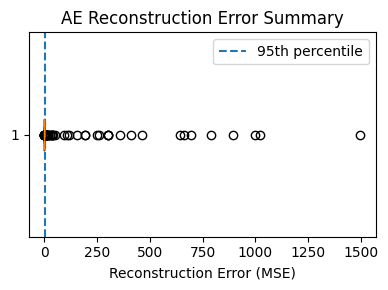

In [49]:
plt.figure(figsize=(4, 3))
plt.boxplot(reconstruction_error_all, vert=False)
plt.axvline(threshold, linestyle="--", label="95th percentile")
plt.xlabel("Reconstruction Error (MSE)")
plt.title("AE Reconstruction Error Summary")
plt.legend()
plt.tight_layout()
plt.show()


Persistence and Labeling of Autoencoder Anomaly Detection Results

Following threshold-based classification, the autoencoder anomaly detection outputs are consolidated and prepared for persistent storage. A human-readable label is first derived from the binary anomaly indicators, assigning the label “anomaly” to transactions classified as anomalous and “normal” to those classified as typical. This labeling facilitates interpretability and simplifies downstream analysis and reporting.

A results table is then constructed containing the transaction identifier, the binary autoencoder anomaly label, the corresponding readable label, and the continuous reconstruction error score. In addition, the selected anomaly threshold is included as metadata for each record, ensuring transparency and traceability of the classification criterion used to derive the anomaly labels.

The resulting dataset is saved to a structured output file, enabling consistent reuse of the autoencoder results across subsequent analysis stages, validation workflows, or integration with other anomaly detection outputs. Storing both continuous scores and discrete labels preserves analytical flexibility, allowing results to be reinterpreted or re-thresholded without retraining the model.

In [50]:
ae_threshold = threshold
# Add readable label
df["ae_label"] = np.where(df["ae_anomaly"] == -1, "anomaly", "normal")

# Save AE results
ae_results = df[[
    "transactionHash",
    "ae_anomaly",
    "ae_label",
    "ae_reconstruction_error"
]].copy()

# Add threshold as metadata column
ae_results["ae_threshold"] = ae_threshold

ae_results.to_csv(
    "../results/autoencoder_results.csv",
    index=False
)

print("Autoencoder results saved.")
print(ae_results["ae_label"].value_counts())
ae_results.head()


Autoencoder results saved.
ae_label
normal     950
anomaly     50
Name: count, dtype: int64


,transactionHash,ae_anomaly,ae_label,ae_reconstruction_error,ae_threshold
0,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,-1,anomaly,2.420245,2.288845
1,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,1,normal,2.238784,2.288845
2,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,1,normal,1.353680,2.288845
3,0x070379239598fdeaed5cf8910f87135c55783fb75778...,1,normal,1.298518,2.288845
4,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,1,normal,1.440844,2.288845
